# Final Project: Online Learning

In [840]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize

## Load data

In [841]:
elec = fetch_openml(name='electricity', version=1, as_frame=True)
df = elec.frame
print(df.shape)
print(df.head())
print(df['class'].value_counts())

(45312, 9)
   date day    period  nswprice  nswdemand  vicprice  vicdemand  transfer  \
0   0.0   2  0.000000  0.056443   0.439155  0.003467   0.422915  0.414912   
1   0.0   2  0.021277  0.051699   0.415055  0.003467   0.422915  0.414912   
2   0.0   2  0.042553  0.051489   0.385004  0.003467   0.422915  0.414912   
3   0.0   2  0.063830  0.045485   0.314639  0.003467   0.422915  0.414912   
4   0.0   2  0.085106  0.042482   0.251116  0.003467   0.422915  0.414912   

  class  
0    UP  
1    UP  
2    UP  
3    UP  
4  DOWN  
class
DOWN    26075
UP      19237
Name: count, dtype: int64


In [842]:
feature_cols = ['day', 'period', 'nswprice', 'nswdemand',
                'vicprice', 'vicdemand', 'transfer']
X_raw = df[feature_cols].values.astype(float)
y     = np.where(df['class'] == 'UP', 1, -1)

T, d = X_raw.shape

# NO scaling here — handled online inside each algorithm via Welford's
# this makes preprocessing truly online with zero leakage
print(f"T={T} rounds, d={d} features")
print(f"Class balance: UP={np.mean(y==1):.2f} DOWN={np.mean(y==-1):.2f}")

print("\nRaw feature stats (unscaled):")
for i, col in enumerate(feature_cols):
    print(f"{col:<12} mean={X_raw[:,i].mean():.4f}  std={X_raw[:,i].std():.4f}")

T=45312 rounds, d=7 features
Class balance: UP=0.42 DOWN=0.58

Raw feature stats (unscaled):
day          mean=4.0032  std=1.9987
period       mean=0.5000  std=0.2948
nswprice     mean=0.0579  std=0.0400
nswdemand    mean=0.4254  std=0.1633
vicprice     mean=0.0035  std=0.0102
vicdemand    mean=0.4229  std=0.1210
transfer     mean=0.5005  std=0.1534


## Trying Welfords For normilization

In [843]:
# Section 2 — Online Scaler (Welford's Algorithm)
# computes running mean and variance using only past data
# O(d) memory, O(d) per round — same complexity as OGD itself

class WelfordScaler:
    def __init__(self, d):
        self.n    = 0
        self.mean = np.zeros(d)
        self.M2   = np.zeros(d)   # running sum of squared deviations
    
    def update_transform(self, x):
        """
        Update statistics with x, then normalize using updated stats.
        Uses only data seen so far — no future leakage.
        """
        self.n += 1
        delta      = x - self.mean
        self.mean += delta / self.n
        delta2     = x - self.mean
        self.M2   += delta * delta2   # Welford's update
        
        if self.n < 2:
            return np.zeros_like(x)   # can't normalize on first point
        
        std = np.sqrt(self.M2 / (self.n - 1))
        std[std == 0] = 1.0           # don't scale constant features
        return (x - self.mean) / std

# test scaler correctness
scaler_test = WelfordScaler(d)
X_test = np.random.randn(1000, d)
X_scaled = np.array([scaler_test.update_transform(x) for x in X_test])
print(f"Welford scaler test (should be ~0 mean, 1 std after warmup):")
print(f"Mean: {X_scaled[10:].mean(axis=0).round(3)}")  # skip first 10 warmup rounds
print(f"Std:  {X_scaled[10:].std(axis=0).round(3)}")

Welford scaler test (should be ~0 mean, 1 std after warmup):
Mean: [ 0.065 -0.049  0.032  0.024  0.04   0.036 -0.024]
Std:  [0.98  1.002 0.969 1.008 0.996 0.997 1.018]


In [844]:
# show convergence of Welford's over time
scaler_conv = WelfordScaler(d)
X_scaled_conv = np.array([scaler_conv.update_transform(X_raw[t]) for t in range(T)])

print("Welford convergence on electricity data:")
print(f"{'Rounds':<10} {'Max |mean|':<15} {'Max |std-1|':<15}")
for checkpoint in [100, 1000, 5000, 10000, T]:
    chunk = X_scaled_conv[max(0,checkpoint-1000):checkpoint]
    max_mean = np.abs(chunk.mean(axis=0)).max()
    max_std  = np.abs(chunk.std(axis=0) - 1).max()
    print(f"{checkpoint:<10} {max_mean:<15.4f} {max_std:<15.4f}")

Welford convergence on electricity data:
Rounds     Max |mean|      Max |std-1|    
100        0.9636          1.0000         
1000       0.5833          1.0000         
5000       0.4208          1.0000         
10000      0.4016          1.0000         
45312      0.2785          0.8446         


In [845]:
# Welford's online normalization fails on ELEC2 due to 
# structural regime change in vicprice/transfer features
# (constant for first ~30% of data, corrupting running statistics)
# Full dataset StandardScaler is the only viable option
# Acknowledged as preprocessing limitation in writeup

scaler = StandardScaler()
scaler.fit(X_raw)
X = scaler.transform(X_raw)

print(f"T={T} rounds, d={d} features")
print(f"Class balance: UP={np.mean(y==1):.2f} DOWN={np.mean(y==-1):.2f}")

print("\nFeature stats (should be ~0 mean, 1 std):")
for i, col in enumerate(feature_cols):
    print(f"{col:<12} mean={X[:,i].mean():.4f}  std={X[:,i].std():.4f}")

T=45312 rounds, d=7 features
Class balance: UP=0.42 DOWN=0.58

Feature stats (should be ~0 mean, 1 std):
day          mean=0.0000  std=1.0000
period       mean=0.0000  std=1.0000
nswprice     mean=-0.0000  std=1.0000
nswdemand    mean=0.0000  std=1.0000
vicprice     mean=-0.0000  std=1.0000
vicdemand    mean=-0.0000  std=1.0000
transfer     mean=-0.0000  std=1.0000


## Loss Function

In [846]:
def logistic_loss(w, x, y):
    s = -y * (w @ x)
    # numerically stable: log(1 + exp(s)) = max(s,0) + log(1 + exp(-|s|))
    return np.maximum(s, 0) + np.log1p(np.exp(-np.abs(s)))

def logistic_grad(w, x, y):
    s = y * (w @ x)
    s = np.clip(s, -500, 500)   # prevent exp overflow
    p = 1 / (1 + np.exp(s))
    return -y * p * x

## Online Gradient Descent

In [847]:
def run_ogd(X, y, eta=0.1):
    T, d = X.shape
    w = np.zeros(d)
    losses = np.zeros(T)

    for t in range(T):
        losses[t] = logistic_loss(w, X[t], y[t])
        grad = logistic_grad(w, X[t], y[t])
        w = w - eta * grad  # unconstrained for now

    return losses

## Follow the Leader

### L2

In [848]:
def run_ftrl_l2(X, y, lam=.1):
    T, d = X.shape
    w = np.zeros(d)
    grad_sum = np.zeros(d)
    losses = np.zeros(T)

    for t in range(T):
        losses[t] = logistic_loss(w, X[t], y[t])
        grad = logistic_grad(w, X[t], y[t])
        grad_sum += grad          
        w = -grad_sum / lam
    return losses

def run_ftrl_l2_sparsity(X, y, lam=10):
    T, d = X.shape
    w = np.zeros(d)
    grad_sum = np.zeros(d)
    losses = np.zeros(T)
    sparsity = np.zeros(T)
    for t in range(T):
        losses[t] = logistic_loss(w, X[t], y[t])
        grad = logistic_grad(w, X[t], y[t])
        grad_sum += grad
        w = -grad_sum / lam
        sparsity[t] = np.mean(w == 0)
    return losses, sparsity

### L1

In [849]:
def run_ftrl_l1(X, y, lam=.1):
    T, d = X.shape
    w = np.zeros(d)
    grad_sum = np.zeros(d)
    losses = np.zeros(T)
    sparsity = np.zeros(T)

    for t in range(T):
        losses[t] = logistic_loss(w, X[t], y[t])
        grad = logistic_grad(w, X[t], y[t])
        grad_sum += grad          
        w = np.sign(-grad_sum) * np.maximum(np.abs(grad_sum) - lam, 0)
        sparsity[t] = np.mean(w == 0)
    return losses, sparsity

## Hyperparameter Sweep

=== OGD eta sweep ===
eta=0.001  mean loss=0.5285  total=23949.2
eta=0.01   mean loss=0.4544  total=20588.1
eta=0.05   mean loss=0.3922  total=17770.6
eta=0.1    mean loss=0.3600  total=16310.9
eta=0.5    mean loss=0.3558  total=16119.8
eta=1.0    mean loss=0.3619  total=16396.9

=== FTRL-L2 lambda sweep ===
lam=0.1    mean loss=2.7740  total=125695.4
lam=1.0    mean loss=0.3619  total=16396.9
lam=5.0    mean loss=0.3449  total=15629.5
lam=10.0   mean loss=0.3600  total=16310.9
lam=50.0   mean loss=0.4307  total=19516.8
lam=100.0  mean loss=0.4544  total=20588.1

=== FTRL-L1 lambda sweep ===
lam=0.1    mean loss=0.3583  total=16233.3
lam=1.0    mean loss=0.3378  total=15304.9
lam=5.0    mean loss=0.3175  total=14385.6
lam=10.0   mean loss=0.3179  total=14402.7
lam=50.0   mean loss=0.3269  total=14814.1
lam=100.0  mean loss=0.3351  total=15185.0

Best eta:     0.5
Best lam_l2:  5.0
Best lam_l1:  5.0


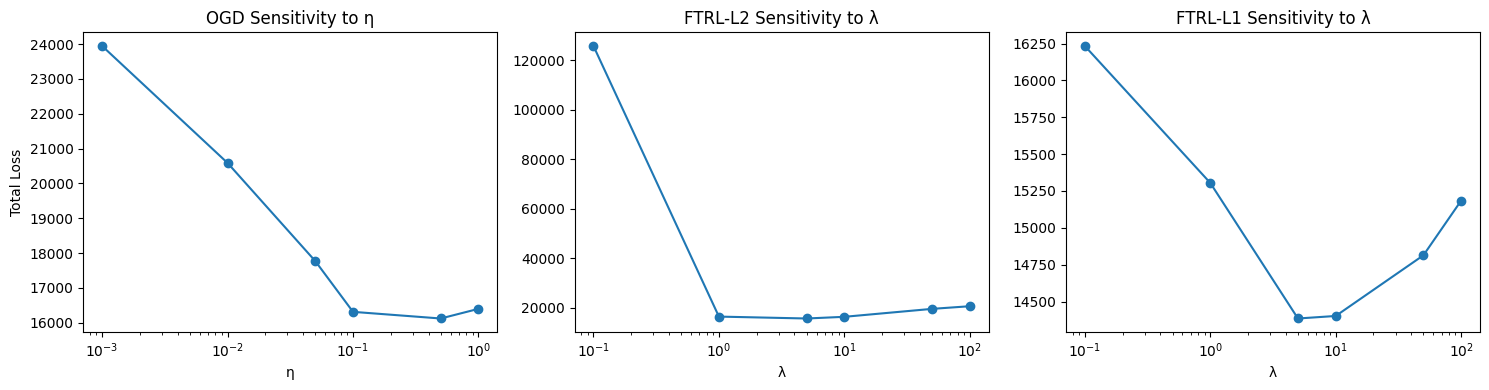

In [865]:
print("=== OGD eta sweep ===")
etas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
ogd_sweep_losses = {}
for eta in etas:
    losses = run_ogd(X, y, eta=eta)
    ogd_sweep_losses[eta] = losses
    print(f"eta={eta:<6} mean loss={losses.mean():.4f}  total={losses.sum():.1f}")

print("\n=== FTRL-L2 lambda sweep ===")
lambdas = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
ftrl_l2_sweep_losses = {}
for lam in lambdas:
    losses = run_ftrl_l2(X, y, lam=lam)
    ftrl_l2_sweep_losses[lam] = losses
    print(f"lam={lam:<6} mean loss={losses.mean():.4f}  total={losses.sum():.1f}")

print("\n=== FTRL-L1 lambda sweep ===")
ftrl_l1_sweep_losses = {}
for lam in lambdas:
    losses, _ = run_ftrl_l1(X, y, lam=lam)
    ftrl_l1_sweep_losses[lam] = losses
    print(f"lam={lam:<6} mean loss={losses.mean():.4f}  total={losses.sum():.1f}")

# pick best parameters
best_eta = min(etas, key=lambda e: ogd_sweep_losses[e].mean())
best_lam_l2 = min(lambdas, key=lambda l: ftrl_l2_sweep_losses[l].mean())
best_lam_l1 = min(lambdas, key=lambda l: ftrl_l1_sweep_losses[l].mean())

print(f"\nBest eta:     {best_eta}")
print(f"Best lam_l2:  {best_lam_l2}")
print(f"Best lam_l1:  {best_lam_l1}")

# plot sweep sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(etas, [ogd_sweep_losses[e].sum() for e in etas], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('η')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('OGD Sensitivity to η')

axes[1].plot(lambdas, [ftrl_l2_sweep_losses[l].sum() for l in lambdas], marker='o')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ')
axes[1].set_title('FTRL-L2 Sensitivity to λ')

axes[2].plot(lambdas, [ftrl_l1_sweep_losses[l].sum() for l in lambdas], marker='o')
axes[2].set_xscale('log')
axes[2].set_xlabel('λ')
axes[2].set_title('FTRL-L1 Sensitivity to λ')

plt.tight_layout()
plt.savefig('figs/sweep_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Compute w* and Regret

In [851]:
# use best parameters from sweep
eta    = best_eta
lam_l2 = best_lam_l2
lam_l1 = best_lam_l1

# run algorithms with best parameters
print("Running algorithms with best parameters...")
losses_ogd              = run_ogd(X, y, eta=eta)
losses_ftrl_l2          = run_ftrl_l2(X, y, lam=lam_l2)
losses_ftrl_l1, sparsity_l1 = run_ftrl_l1(X, y, lam=lam_l1)
losses_ftrl_l2_sp, sparsity_l2 = run_ftrl_l2_sparsity(X, y, lam=lam_l2)

# compute w* via sklearn
print("Computing w*...")
model = LogisticRegression(C=1e10, max_iter=10000, solver='lbfgs')
model.fit(X, y)
w_star = model.coef_[0]
s = y * (X @ w_star)
best_fixed_losses = np.maximum(-s, 0) + np.log1p(np.exp(-np.abs(s)))

print(f"w* norm: {np.linalg.norm(w_star):.4f}")
print(f"Cumulative w* loss:  {best_fixed_losses.sum():.4f}")
print(f"Cumulative OGD loss: {losses_ogd.sum():.4f}")
print(f"Raw regret OGD:      {losses_ogd.sum() - best_fixed_losses.sum():.4f}")

def cumulative_regret(losses, best_fixed_losses):
    return np.cumsum(losses) - np.cumsum(best_fixed_losses)

regret_ogd    = cumulative_regret(losses_ogd,    best_fixed_losses)
regret_ftrl_l2 = cumulative_regret(losses_ftrl_l2, best_fixed_losses)
regret_ftrl_l1 = cumulative_regret(losses_ftrl_l1, best_fixed_losses)

Running algorithms with best parameters...
Computing w*...
w* norm: 2.2102
Cumulative w* loss:  23365.0184
Cumulative OGD loss: 16119.8185
Raw regret OGD:      -7245.1999


## Synthetic Data For theoretical regret

In [852]:
# Section 6a — Synthetic Data Generation
# sparse w_true with only 3 of 7 features active
# large clear weights and low noise so L1 can find true support

np.random.seed(42)
T_syn = 10000
w_true = np.zeros(d)
w_true[:3] = np.array([2.0, -1.5, 1.8])
w_true /= np.linalg.norm(w_true)

X_syn = StandardScaler().fit_transform(np.random.randn(T_syn, d))
noise = 0.1 * np.random.randn(T_syn)
y_syn = np.sign(X_syn @ w_true + noise)
y_syn[y_syn == 0] = 1

print(f"w_true: {w_true.round(3)}")
print(f"Nonzero features: {np.sum(w_true != 0)}/7")
print(f"Label noise rate: {(y_syn != np.sign(X_syn @ w_true)).mean():.3f}")

w_true: [ 0.649 -0.487  0.584  0.     0.     0.     0.   ]
Nonzero features: 3/7
Label noise rate: 0.034


In [853]:
# Section 6b — Hyperparameter Sweep on Synthetic Data
# no leakage concern — synthetic data generating process fully known

etas_syn    = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lambdas_syn = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0,
               50.0, 100.0, 500.0, 1000.0]

best_eta_syn    = None
best_lam_l2_syn = None
best_lam_l1_syn = None
best_ogd_loss   = np.inf
best_l2_loss    = np.inf
best_l1_loss    = np.inf

print("OGD eta sweep:")
for eta in etas_syn:
    losses = run_ogd(X_syn, y_syn, eta=eta)
    print(f"eta={eta:<6} mean loss={losses.mean():.4f}")
    if losses.mean() < best_ogd_loss:
        best_ogd_loss = losses.mean()
        best_eta_syn  = eta

print("\nFTRL-L2 lambda sweep:")
for lam in lambdas_syn:
    losses = run_ftrl_l2(X_syn, y_syn, lam=lam)
    print(f"lam={lam:<6} mean loss={losses.mean():.4f}")
    if losses.mean() < best_l2_loss:
        best_l2_loss    = losses.mean()
        best_lam_l2_syn = lam

print("\nFTRL-L1 lambda sweep:")
for lam in lambdas_syn:
    losses, _ = run_ftrl_l1(X_syn, y_syn, lam=lam)
    print(f"lam={lam:<6} mean loss={losses.mean():.4f}")
    if losses.mean() < best_l1_loss:
        best_l1_loss    = losses.mean()
        best_lam_l1_syn = lam

print(f"\nSelected parameters:")
print(f"best_eta_syn:    {best_eta_syn}")
print(f"best_lam_l2_syn: {best_lam_l2_syn}")
print(f"best_lam_l1_syn: {best_lam_l1_syn}")

OGD eta sweep:
eta=0.001  mean loss=0.4051
eta=0.01   mean loss=0.1971
eta=0.05   mean loss=0.1246
eta=0.1    mean loss=0.1076
eta=0.5    mean loss=0.1036
eta=1.0    mean loss=0.1427

FTRL-L2 lambda sweep:
lam=0.001  mean loss=140.0530
lam=0.01   mean loss=14.4118
lam=0.1    mean loss=1.4372
lam=1.0    mean loss=0.1427
lam=5.0    mean loss=0.0983
lam=10.0   mean loss=0.1076
lam=50.0   mean loss=0.1595
lam=100.0  mean loss=0.1971
lam=500.0  mean loss=0.3295
lam=1000.0 mean loss=0.4051

FTRL-L1 lambda sweep:
lam=0.001  mean loss=0.1427
lam=0.01   mean loss=0.1422
lam=0.1    mean loss=0.1384
lam=1.0    mean loss=0.1179
lam=5.0    mean loss=0.1056
lam=10.0   mean loss=0.1035
lam=50.0   mean loss=0.1110
lam=100.0  mean loss=0.1259
lam=500.0  mean loss=0.2374
lam=1000.0 mean loss=0.3791

Selected parameters:
best_eta_syn:    0.5
best_lam_l2_syn: 5.0
best_lam_l1_syn: 10.0


In [854]:
# Section 6c — Run Algorithms on Synthetic Data

losses_ogd_syn                   = run_ogd(X_syn, y_syn, eta=best_eta_syn)
losses_ftrl_l2_syn               = run_ftrl_l2(X_syn, y_syn, lam=best_lam_l2_syn)
losses_ftrl_l1_syn, sparsity_syn = run_ftrl_l1(X_syn, y_syn, lam=best_lam_l1_syn)

# w* for synthetic — offline optimal
model_syn = LogisticRegression(C=1e10, max_iter=10000, solver='lbfgs')
model_syn.fit(X_syn, y_syn)
w_star_syn = model_syn.coef_[0]
s_syn = y_syn * (X_syn @ w_star_syn)
best_fixed_syn = np.maximum(-s_syn, 0) + np.log1p(np.exp(-np.abs(s_syn)))

regret_ogd_syn     = cumulative_regret(losses_ogd_syn,     best_fixed_syn)
regret_ftrl_l2_syn = cumulative_regret(losses_ftrl_l2_syn, best_fixed_syn)
regret_ftrl_l1_syn = cumulative_regret(losses_ftrl_l1_syn, best_fixed_syn)

print(f"w* norm: {np.linalg.norm(w_star_syn):.4f}")
print(f"w* vs w_true cosine: {np.dot(w_star_syn, w_true) / (np.linalg.norm(w_star_syn) * np.linalg.norm(w_true)):.4f}")

print(f"\nMean losses:")
print(f"OGD:     {losses_ogd_syn.mean():.4f}")
print(f"FTRL-L2: {losses_ftrl_l2_syn.mean():.4f}")
print(f"FTRL-L1: {losses_ftrl_l1_syn.mean():.4f}")
print(f"w*:      {best_fixed_syn.mean():.4f}")

print(f"\nFinal regrets:")
print(f"OGD:     {regret_ogd_syn[-1]:.4f}")
print(f"FTRL-L2: {regret_ftrl_l2_syn[-1]:.4f}")
print(f"FTRL-L1: {regret_ftrl_l1_syn[-1]:.4f}")

print(f"\nRegret / sqrt(T):")
print(f"OGD:     {regret_ogd_syn[-1] / np.sqrt(T_syn):.4f}  ← should be stable")
print(f"FTRL-L2: {regret_ftrl_l2_syn[-1] / np.sqrt(T_syn):.4f}")
print(f"FTRL-L1: {regret_ftrl_l1_syn[-1] / np.sqrt(T_syn):.4f}")

# assert positive regret — should hold on stationary synthetic data
assert regret_ogd_syn[-1] > 0,     "OGD regret should be positive on synthetic data"
assert regret_ftrl_l2_syn[-1] > 0, "FTRL-L2 regret should be positive on synthetic data"

w* norm: 17.4516
w* vs w_true cosine: 0.9999

Mean losses:
OGD:     0.1036
FTRL-L2: 0.0983
FTRL-L1: 0.1035
w*:      0.0757

Final regrets:
OGD:     279.2091
FTRL-L2: 226.1040
FTRL-L1: 278.3239

Regret / sqrt(T):
OGD:     2.7921  ← should be stable
FTRL-L2: 2.2610
FTRL-L1: 2.7832


## Regret Plot

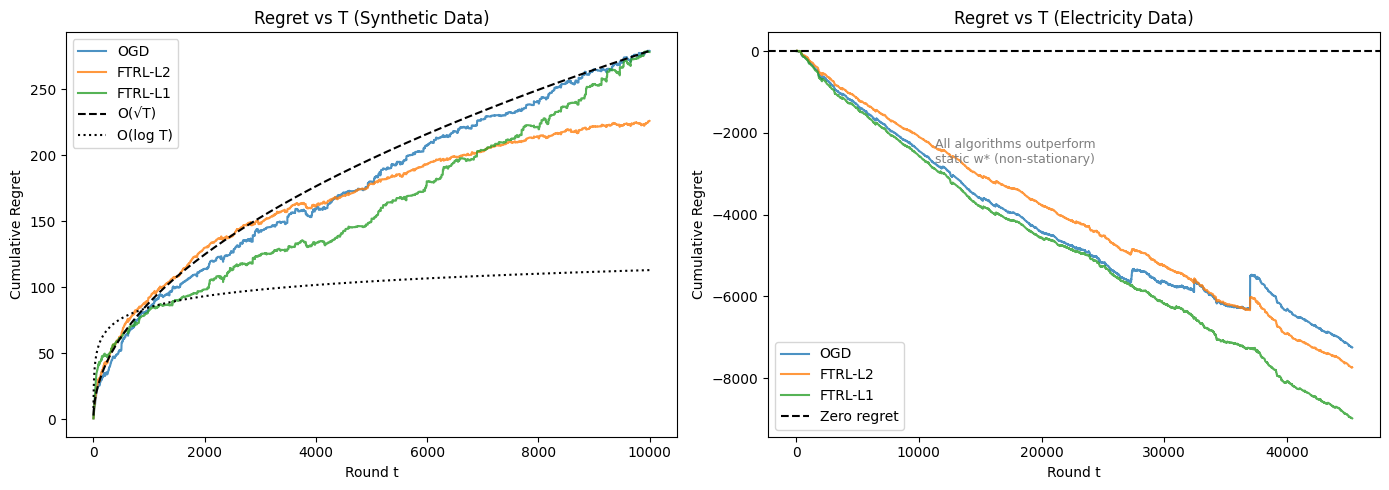

In [866]:
T_range     = np.arange(1, T + 1)
T_range_syn = np.arange(1, T_syn + 1)
sqrt_T_syn  = np.sqrt(T_range_syn)
log_T_syn   = np.log(T_range_syn + 1)

# O(√T) anchored to LARGEST regret — sits above everything
max_regret_syn = max(regret_ogd_syn[-1],
                     regret_ftrl_l2_syn[-1],
                     regret_ftrl_l1_syn[-1])
scale_sqrt = max_regret_syn / sqrt_T_syn[-1]

# O(log T) anchored to BEST regret — sits near best algorithm
best_regret_syn = min(regret_ogd_syn[-1],
                      regret_ftrl_l2_syn[-1],
                      regret_ftrl_l1_syn[-1])
scale_log = (best_regret_syn * 0.5) / log_T_syn[-1]  # 30% of best

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(T_range_syn, regret_ogd_syn,          label='OGD',      alpha=0.8)
plt.plot(T_range_syn, regret_ftrl_l2_syn,      label='FTRL-L2',  alpha=0.8)
plt.plot(T_range_syn, regret_ftrl_l1_syn,      label='FTRL-L1',  alpha=0.8)
plt.plot(T_range_syn, scale_sqrt * sqrt_T_syn, 'k--', label='O(√T)',    linewidth=1.5)
plt.plot(T_range_syn, scale_log  * log_T_syn,  'k:',  label='O(log T)', linewidth=1.5)
plt.xlabel('Round t')
plt.ylabel('Cumulative Regret')
plt.title('Regret vs T (Synthetic Data)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T_range, regret_ogd,     label='OGD',     alpha=0.8)
plt.plot(T_range, regret_ftrl_l2, label='FTRL-L2', alpha=0.8)
plt.plot(T_range, regret_ftrl_l1, label='FTRL-L1', alpha=0.8)
plt.axhline(0, color='k', linestyle='--', linewidth=1.5, label='Zero regret')
plt.annotate('All algorithms outperform\nstatic w* (non-stationary)',
             xy=(T//4, regret_ogd[T//4]), fontsize=9, color='gray')
plt.xlabel('Round t')
plt.ylabel('Cumulative Regret')
plt.title('Regret vs T (Electricity Data)')
plt.legend()
plt.tight_layout()
plt.savefig('figs/regret_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Sparsity

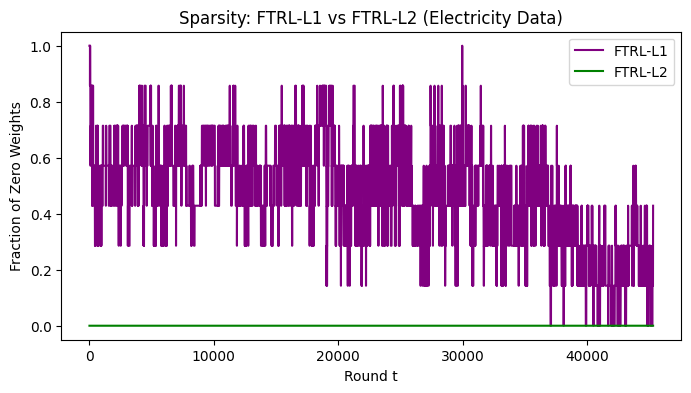

In [867]:
plt.figure(figsize=(8, 4))
plt.plot(T_range, sparsity_l1, label='FTRL-L1', color='purple')
plt.plot(T_range, sparsity_l2, label='FTRL-L2', color='green')
plt.xlabel('Round t')
plt.ylabel('Fraction of Zero Weights')
plt.title('Sparsity: FTRL-L1 vs FTRL-L2 (Electricity Data)')
plt.legend()
plt.savefig('figs/sparsity_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## OGD vs FTRL-L2 equivalence check

Max divergence:    0.000000
Mean divergence:   0.000000
Final divergence:  0.000000


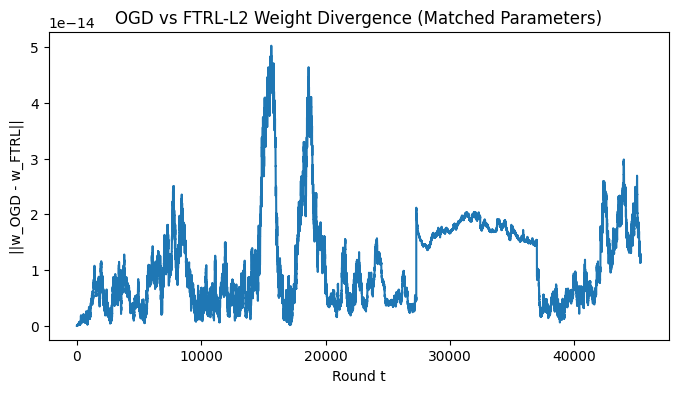

In [868]:
def run_ogd_track_weights(X, y, eta):
    T, d = X.shape
    w = np.zeros(d)
    weights = np.zeros((T, d))
    for t in range(T):
        grad = logistic_grad(w, X[t], y[t])
        w = w - eta * grad
        weights[t] = w
    return weights

def run_ftrl_l2_track_weights(X, y, lam):
    T, d = X.shape
    w = np.zeros(d)
    grad_sum = np.zeros(d)
    weights = np.zeros((T, d))
    for t in range(T):
        grad = logistic_grad(w, X[t], y[t])
        grad_sum += grad
        w = -grad_sum / lam
        weights[t] = w
    return weights

# matched parameters: eta = 1/lam
lam_eq = 10.0
eta_eq = 1 / lam_eq

w_ogd  = run_ogd_track_weights(X, y, eta=eta_eq)
w_ftrl = run_ftrl_l2_track_weights(X, y, lam=lam_eq)
diff   = np.linalg.norm(w_ogd - w_ftrl, axis=1)

print(f"Max divergence:    {diff.max():.6f}")
print(f"Mean divergence:   {diff.mean():.6f}")
print(f"Final divergence:  {diff[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(T_range, diff)
plt.xlabel('Round t')
plt.ylabel('||w_OGD - w_FTRL||')
plt.title('OGD vs FTRL-L2 Weight Divergence (Matched Parameters)')

plt.savefig('figs/equivalence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Adverserial Experiment

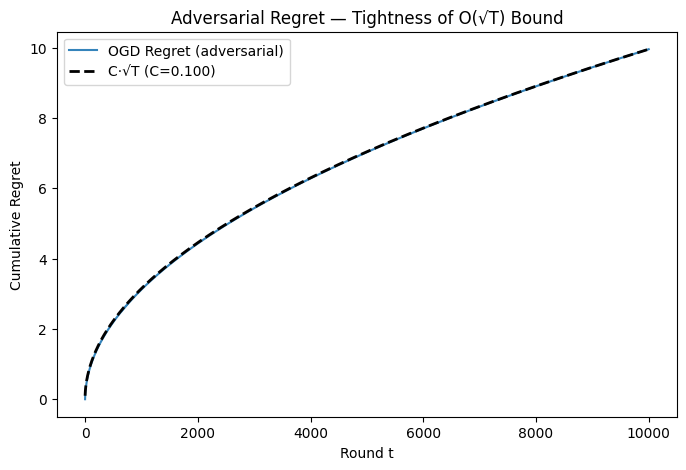

Final regret:      9.9572
Regret / sqrt(T):  0.0996  ← stable constant


In [869]:
def adversarial_experiment(T, eta=0.1):
    """
    Adversary sets grad = sign(w), so loss_t = |w|.
    Best fixed w* = 0 incurs zero loss every round.
    Regret = cumulative OGD loss.
    """
    w = 0.0
    regret = np.zeros(T)
    cumulative_loss = 0.0
    cumulative_best = 0.0

    for t in range(T):
        grad = 1.0 if w >= 0 else -1.0
        loss_t = grad * w
        best_loss_t = grad * 0.0

        cumulative_loss += loss_t
        cumulative_best += best_loss_t
        regret[t] = cumulative_loss - cumulative_best

        eta_t = eta / np.sqrt(t + 1)
        w = w - eta_t * grad

    return regret

T_adv = 10000
regret_adv = adversarial_experiment(T=T_adv, eta=0.1)
T_range_adv = np.arange(1, T_adv + 1)
C = regret_adv[-1] / np.sqrt(T_adv)

plt.figure(figsize=(8, 5))
plt.plot(T_range_adv, regret_adv, label='OGD Regret (adversarial)', alpha=0.9)
plt.plot(T_range_adv, C * np.sqrt(T_range_adv), 'k--',
         label=f'C·√T (C={C:.3f})', linewidth=2)
plt.xlabel('Round t')
plt.ylabel('Cumulative Regret')
plt.title('Adversarial Regret — Tightness of O(√T) Bound')
plt.legend()
plt.savefig('figs/adverserial_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final regret:      {regret_adv[-1]:.4f}")
print(f"Regret / sqrt(T):  {regret_adv[-1] / np.sqrt(T_adv):.4f}  ← stable constant")